In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("../data/raw/Mall_Customers.csv")

Can we discover different types of customers based on their age, income and spending behaviour?

### EDA

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print("# of records: ",len(df))
print('# of columns: ',len(df.columns))

# of records:  200
# of columns:  5


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Feature Selection

In [8]:
# Removing customerID as it has no relationship with behaviour, and model may overfit and think Customer 100 is somehow different from Customer 1
df.drop('CustomerID',inplace=True,axis=1)

In [9]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [10]:
df.to_csv('../data/clean/Mall_Customers.csv', index=False) 

### Visualization
- Understanding features visually

In [11]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [12]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


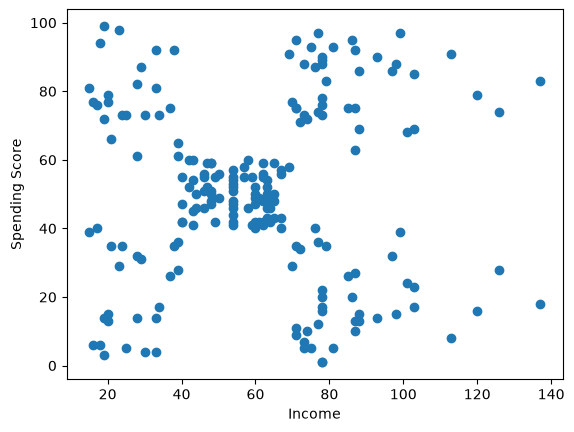

In [13]:
# Income vs Spending
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

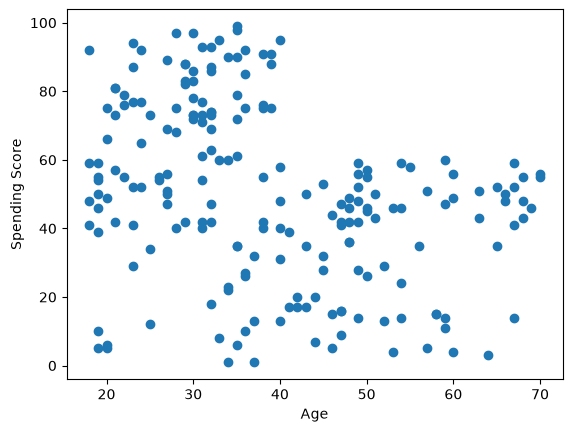

In [14]:
# Age vs Spending Score
plt.scatter(df['Age'],df['Spending Score (1-100)'])
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.show()

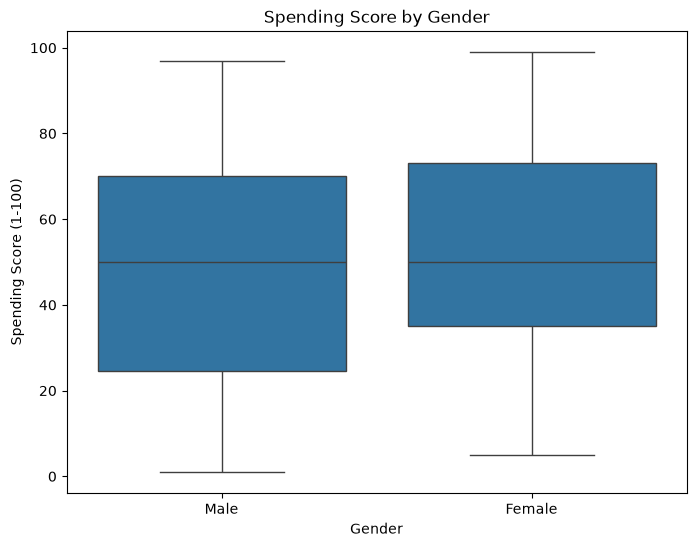

In [15]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df,x='Gender',y='Spending Score (1-100)')
plt.title('Spending Score by Gender')
plt.show()


In [16]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


### Data Preparation

#### Encoder

In [17]:
feature1=df.drop('Gender',axis=1)
feature1.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [18]:
gndr_dummy=pd.get_dummies(df.Gender,drop_first=True).astype(int)
gndr_dummy.head()

,Male
0,1
1,1
2,0
3,0
4,0


In [19]:
df=pd.concat([df,gndr_dummy],axis=1)
df.drop('Gender',axis=1,inplace=True)

In [20]:

df.head()


,Age,Annual Income (k$),Spending Score (1-100),Male
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


In [21]:
feature2=df
feature2.head()

,Age,Annual Income (k$),Spending Score (1-100),Male
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


#### Standardization

In [22]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [32]:
ss1=StandardScaler()
ss2=StandardScaler()

In [33]:
feature1_scaled=ss1.fit_transform(feature1)
feature2_scaled=ss2.fit_transform(feature2)


### Dimension Reduction using Principal Component Analysis

In [37]:
pca1=PCA(n_components=2)
pca2=PCA(n_components=2)

In [38]:
f1_pca = pca1.fit(feature1_scaled)
f2_pca = pca2.fit(feature2_scaled)

In [ ]:
# total variance in our dataset is captured by each individual principal component
print(f1_pca.explained_variance_)  
print(f2_pca.explained_variance_)

[1.33465831 1.00427272]
[1.35437369 1.05449828]


In [41]:
f1_pca_transformed=pca1.transform(feature1_scaled)
f2_pca_transformed=pca2.transform(feature2_scaled)

In [60]:
pca1.components_.T
loadings_df1=pd.DataFrame(pca1.components_.T,columns=[f"PC_{i+1}" for i in range(len(pca1.components_))],index=feature1.columns)
loadings_df1

,PC_1,PC_2
Age,0.706382,0.030141
Annual Income (k$),-0.048024,0.998832
Spending Score (1-100),-0.706199,-0.037775


In [68]:
pca2.components_.T
loadings_df2=pd.DataFrame(pca2.components_.T,columns=[f"PC_{i+1}" for i in range(len(pca2.components_))],index=feature2.columns)
loadings_df2

,PC_1,PC_2
Age,0.687900,-0.103690
Annual Income (k$),-0.006082,0.765252
Spending Score (1-100),-0.686920,0.103211
Male,0.234302,0.626886


In [42]:
print(f1_pca_transformed)

[[-6.15720019e-01 -1.76348088e+00]
 [-1.66579271e+00 -1.82074695e+00]
 [ 3.37861909e-01 -1.67479894e+00]
 [-1.45657325e+00 -1.77242992e+00]
 [-3.84652078e-02 -1.66274012e+00]
 [-1.48168526e+00 -1.73500173e+00]
 [ 1.09461665e+00 -1.56610230e+00]
 [-1.92630736e+00 -1.72111049e+00]
 [ 2.64517786e+00 -1.46084721e+00]
 [-9.70130513e-01 -1.63558108e+00]
 [ 2.49568861e+00 -1.47048914e+00]
 [-1.45688256e+00 -1.66436050e+00]
 [ 2.01018729e+00 -1.45329897e+00]
 [-1.41321072e+00 -1.61776746e+00]
 [ 1.00042965e+00 -1.49579176e+00]
 [-1.56943170e+00 -1.62502669e+00]
 [ 2.94060318e-01 -1.49425585e+00]
 [-1.31624924e+00 -1.57216383e+00]
 [ 1.31669910e+00 -1.37243404e+00]
 [-1.43679899e+00 -1.51039469e+00]
 [ 2.88561175e-01 -1.37988135e+00]
 [-1.26018513e+00 -1.45723906e+00]
 [ 1.66684303e+00 -1.27396755e+00]
 [-9.57849842e-01 -1.40613544e+00]
 [ 1.82015978e+00 -1.15548636e+00]
 [-1.31148032e+00 -1.30928557e+00]
 [ 8.70423506e-01 -1.20135126e+00]
 [-4.31580912e-01 -1.26551061e+00]
 [ 6.42532610e-01 -1

In [43]:
print(f2_pca_transformed)

[[-4.06382715e-01 -5.20713635e-01]
 [-1.42767287e+00 -3.67310199e-01]
 [ 5.07605706e-02 -1.89406774e+00]
 [-1.69451310e+00 -1.63190805e+00]
 [-3.13108383e-01 -1.81048272e+00]
 [-1.71744627e+00 -1.59926418e+00]
 [ 7.90821124e-01 -1.94727112e+00]
 [-2.14832159e+00 -1.50537369e+00]
 [ 2.77428623e+00 -8.82987672e-01]
 [-1.21629477e+00 -1.61640464e+00]
 [ 2.62905084e+00 -8.61237043e-01]
 [-1.68947038e+00 -1.54542784e+00]
 [ 1.68582253e+00 -2.02394479e+00]
 [-1.64607339e+00 -1.52251259e+00]
 [ 1.17443628e+00 -6.12790961e-01]
 [-1.32613070e+00 -2.36719149e-01]
 [ 1.67728253e-02 -1.74344572e+00]
 [-1.07842454e+00 -2.44715641e-01]
 [ 1.48758780e+00 -5.72676028e-01]
 [-1.66373169e+00 -1.43259774e+00]
 [ 4.88090311e-01 -3.92921145e-01]
 [-1.01895051e+00 -1.66247511e-01]
 [ 1.35891492e+00 -1.82866936e+00]
 [-7.22972722e-01 -1.81687017e-01]
 [ 1.51315931e+00 -1.76451196e+00]
 [-1.06241157e+00 -4.31150614e-02]
 [ 5.88832908e-01 -1.62541614e+00]
 [-2.06188227e-01 -1.71906970e-01]
 [ 3.68426440e-01 -1

In [69]:
print("PCA1_explained_ration: ",pca1.explained_variance_ratio_)
print("PCA2_explained_ration: ",pca2.explained_variance_ratio_)

PCA1_explained_ration:  [0.44266167 0.33308378]
PCA2_explained_ration:  [0.33690046 0.26230645]


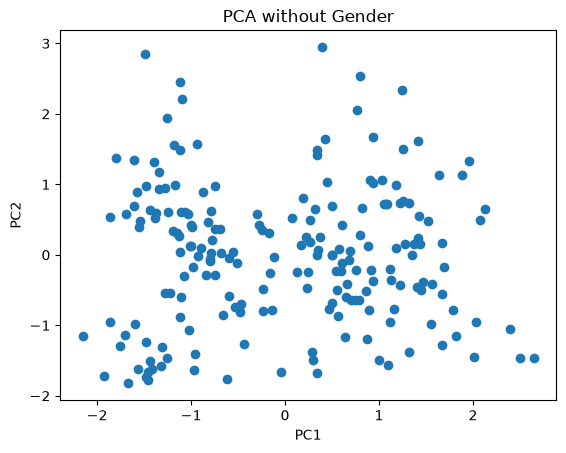

In [70]:
plt.scatter(f1_pca_transformed[:,0],f1_pca_transformed[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA without Gender")
plt.show()

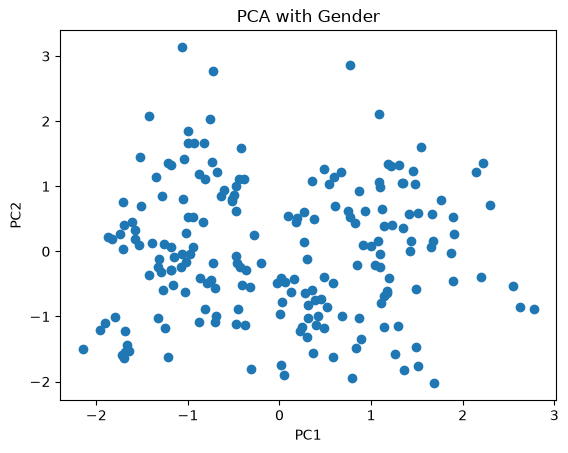

In [72]:
plt.scatter(f2_pca_transformed[:,0],f2_pca_transformed[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA with Gender")
plt.show()

Gender does not create strong pattern, and does not significantly change the customer distribution in the dataset.

### KMeans Clustering

In [74]:
from sklearn.cluster import KMeans

In [80]:
kmean1=KMeans(n_clusters=5,random_state=42)
cluster1=kmean1.fit_predict(f1_pca_transformed)
# type(cluster1)
